# Sleep Disorder Prediction using Machine Learning

## Project Overview

This project aims to predict sleep disorders using machine learning techniques based on lifestyle and health-related factors such as sleep duration, stress levels, BMI, heart rate, and physical activity.

The project includes:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Hyperparameter tuning
- Model evaluation
- Model saving

## Importing Required Libraries

## Loading the Dataset

In [74]:
# LOAD DATASET
# ============================================================

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print(df.head())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200           None  
1         125/80          75      

## Basic Data Analysis

In [ ]:


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())



Dataset Shape:
(374, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memo

## Data Cleaning

In [ ]:


# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values if any
df.fillna(method='ffill', inplace=True)


## Feature Engineering

Blood pressure values were split into:
- Systolic BP
- Diastolic BP

In [ ]:


# Split Blood Pressure column
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

# Drop original column
df.drop('Blood Pressure', axis=1, inplace=True)

print(df.head())


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

   Heart Rate  Daily Steps Sleep Disorder  Systolic_BP  Diastolic_BP  
0          77         4200           None          126            83  
1         

## Exploratory Data Analysis (EDA)

EDA helps identify patterns and relationships between:
- Sleep duration
- Stress levels
- BMI
- Physical activity
- Sleep disorders

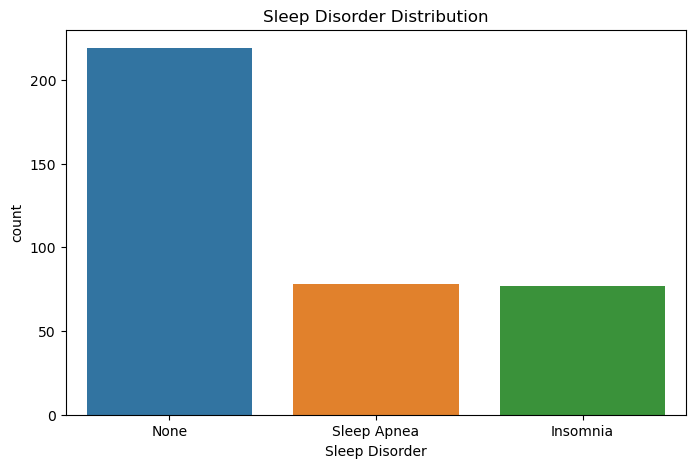

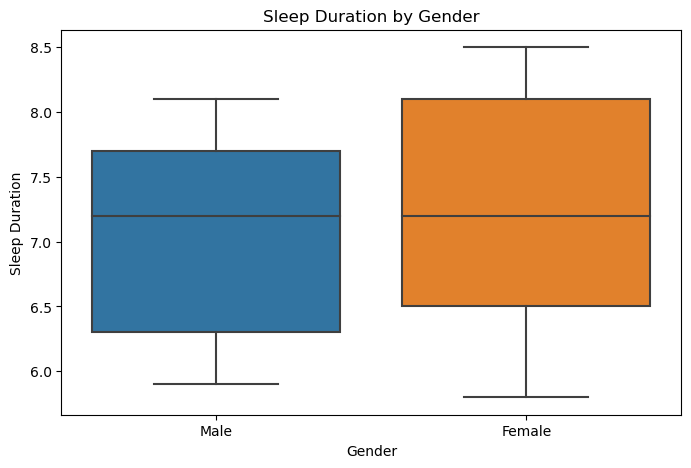

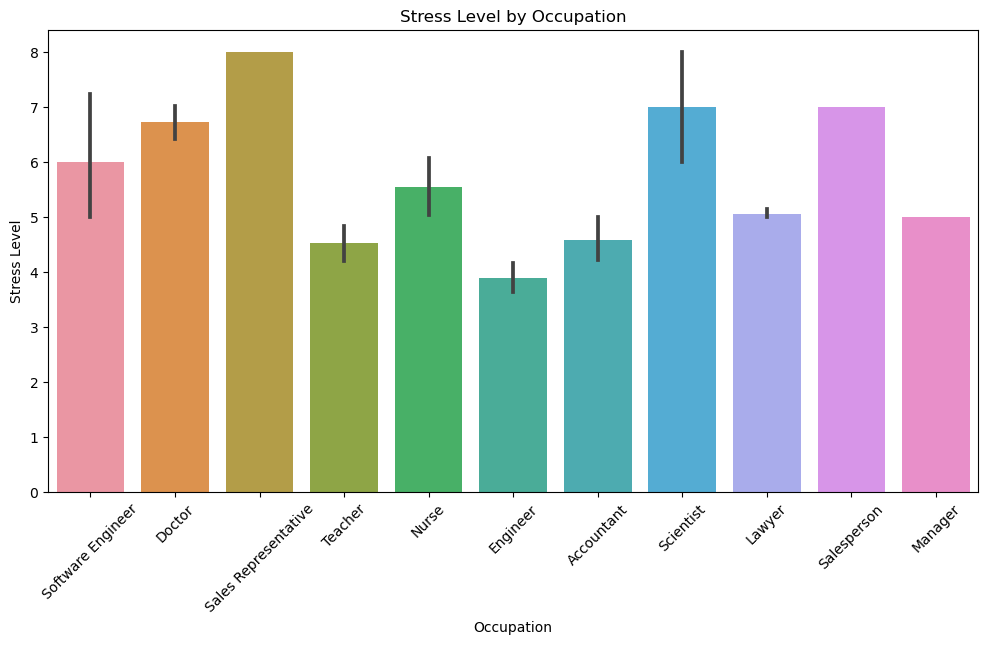

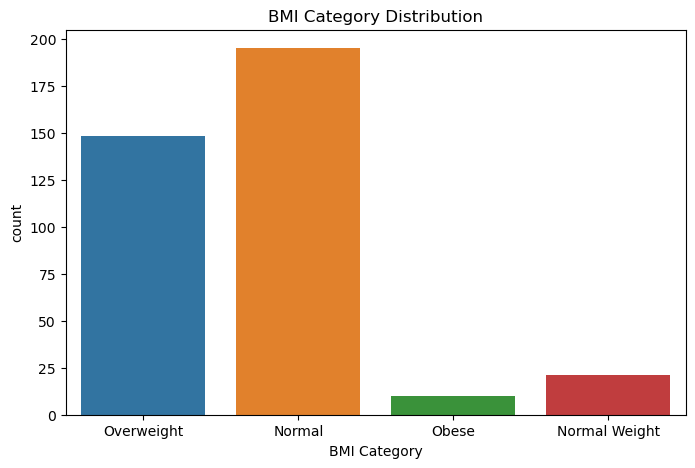

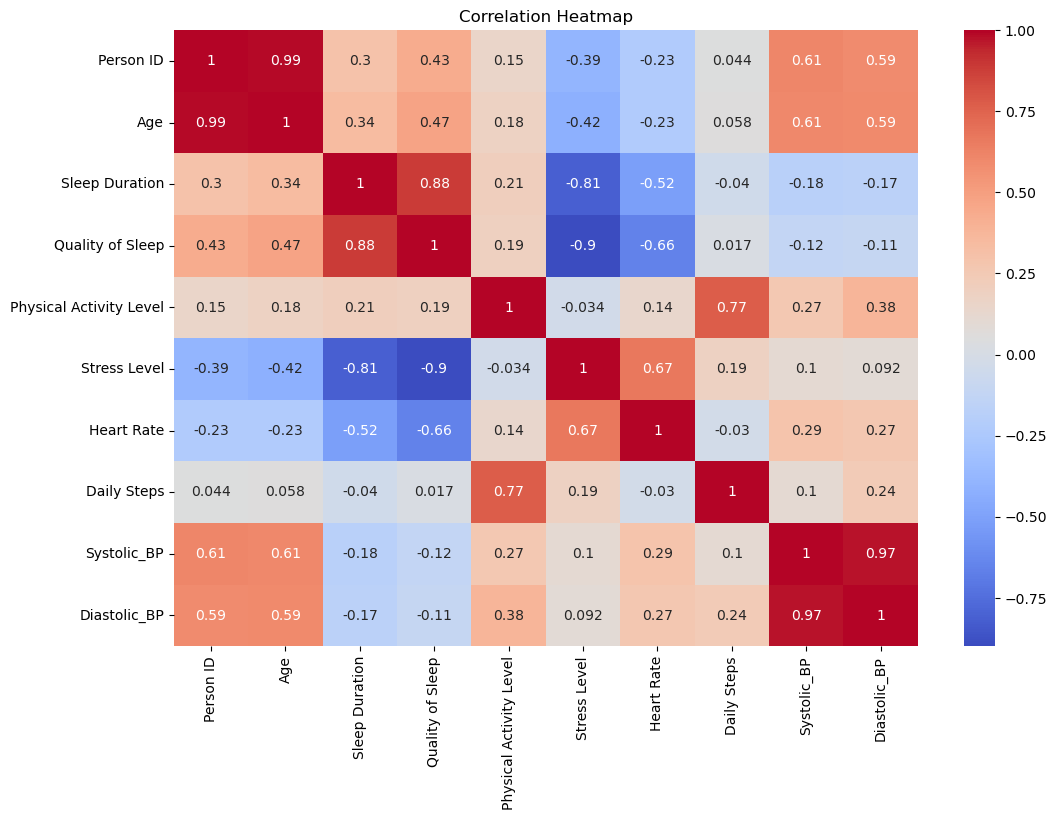

In [ ]:


# Sleep Disorder Count
plt.figure(figsize=(8,5))
sns.countplot(x='Sleep Disorder', data=df)
plt.title("Sleep Disorder Distribution")
plt.show()

# Gender vs Sleep Duration
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Sleep Duration', data=df)
plt.title("Sleep Duration by Gender")
plt.show()

# Stress Level by Occupation
plt.figure(figsize=(12,6))
sns.barplot(x='Occupation', y='Stress Level', data=df)
plt.xticks(rotation=45)
plt.title("Stress Level by Occupation")
plt.show()

# BMI Category Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='BMI Category', data=df)
plt.title("BMI Category Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Encoding Categorical Variables

In [ ]:


encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    if col != 'Sleep Disorder':
        df[col] = encoder.fit_transform(df[col])

# Separate encoder for target column
target_encoder = LabelEncoder()

df['Sleep Disorder'] = target_encoder.fit_transform(df['Sleep Disorder'])

print(target_encoder.classes_)

print(df.head())

['Insomnia' 'None' 'Sleep Apnea']
   Person ID  Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0          1       1   27           9             6.1                 6   
1          2       1   28           1             6.2                 6   
2          3       1   28           1             6.2                 6   
3          4       1   28           6             5.9                 4   
4          5       1   28           6             5.9                 4   

   Physical Activity Level  Stress Level  BMI Category  Blood Pressure  \
0                       42             6             3              11   
1                       60             8             0               9   
2                       60             8             0               9   
3                       30             8             2              22   
4                       30             8             2              22   

   Heart Rate  Daily Steps  Sleep Disorder  
0          77         420

## Define Features And Target

In [ ]:


X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']




## Splitting Dataset into Training and Testing Sets

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


  # Feature Scaling


In [ ]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model Training

Models used:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Random Forest

In [ ]:


# Logistic Regression
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, pred_lr))



Logistic Regression Accuracy:
0.9333333333333333


In [60]:
# KNN MODEL
# ============================================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print("\nKNN Accuracy:")
print(accuracy_score(y_test, pred_knn))


KNN Accuracy:
0.92


In [61]:
# SVM MODEL
# ============================================================

svm = SVC(probability=True)

svm.fit(X_train_scaled, y_train)

pred_svm = svm.predict(X_test_scaled)

print("\nSVM Accuracy:")
print(accuracy_score(y_test, pred_svm))


SVM Accuracy:
0.9733333333333334


In [62]:
# RANDOM FOREST MODEL
# ============================================================

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, pred_rf))



Random Forest Accuracy:
0.9333333333333333


## Cross Validation

In [ ]:


cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())


Cross Validation Scores:
[0.93333333 0.88333333 0.9        0.85       0.88135593]

Average CV Score:
0.8896045197740113


## Hyperparameter Tuning

In [ ]:


param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Score:")
print(grid.best_score_)




Best Parameters:
{'C': 10, 'solver': 'lbfgs'}

Best Score:
0.8929378531073446


## Final Predictions

In [ ]:


y_pred = best_model.predict(X_test_scaled)

print("\nFinal Model Accuracy:")
print(accuracy_score(y_test, y_pred))


Final Model Accuracy:
0.96


## Classification Report

In [ ]:



print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       1.00      0.98      0.99        44
           2       0.89      1.00      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



## Confusion Matrix

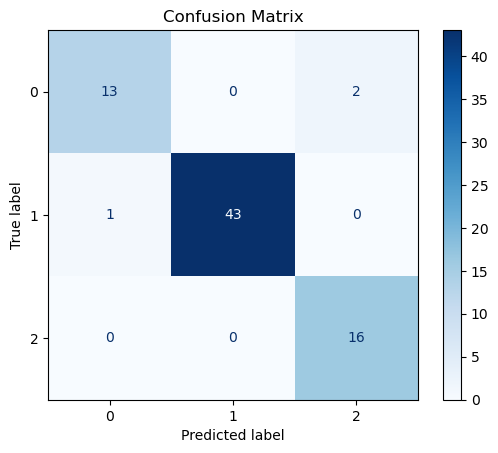

In [ ]:


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()


# ROC Curve

In [ ]:


# Binary classification ROC

if len(np.unique(y)) == 2:

    y_prob = best_model.predict_proba(X_test_scaled)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(8,6))

    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()



## Feature Importance Analysis


Feature Importance:
                    Feature  Coefficient
11              Systolic_BP     1.813644
6   Physical Activity Level     0.717219
2                       Age     0.629056
8              BMI Category     0.440070
1                    Gender     0.258764
0                 Person ID     0.199257
3                Occupation    -0.324047
7              Stress Level    -0.500871
5          Quality of Sleep    -0.862936
10              Daily Steps    -0.957893
9                Heart Rate    -0.965804
4            Sleep Duration    -1.321430
12             Diastolic_BP    -2.114152


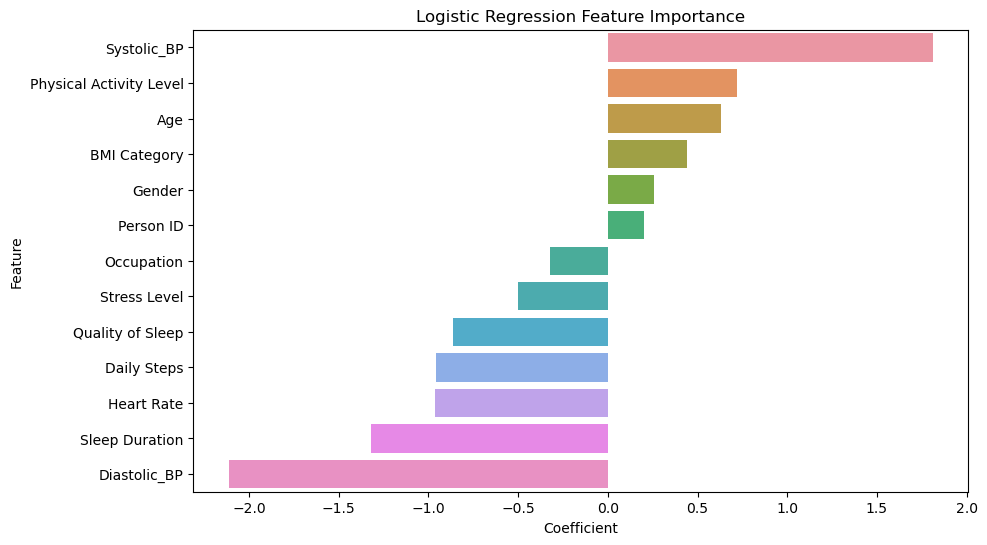

In [ ]:


importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Logistic Regression Feature Importance")

plt.show()

## Pipeline Implementation

In [ ]:


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

print("\nPipeline Accuracy:")
print(accuracy_score(y_test, pipeline_pred))


Pipeline Accuracy:
0.9333333333333333


## Save Model

In [ ]:


joblib.dump(best_model, 'sleep_disorder_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("\nModel and scaler saved successfully.")



Model and scaler saved successfully.


## Load model

In [ ]:


loaded_model = joblib.load('sleep_disorder_model.pkl')

loaded_scaler = joblib.load('scaler.pkl')

print("\nSaved model loaded successfully.")



Saved model loaded successfully.


 ## Sample Prediction Using Trained Model

In [ ]:



sample_data = X.iloc[0:1]

sample_scaled = loaded_scaler.transform(sample_data)

prediction = loaded_model.predict(sample_scaled)

predicted_label = target_encoder.inverse_transform(prediction)

print("\nPredicted Sleep Disorder:")
print(predicted_label[0])


Predicted Sleep Disorder:
None


In [80]:
sample_data = pd.DataFrame([{
    'Person ID': 400,
    'Gender': 1,
    'Age': 52,
    'Occupation': 5,
    'Sleep Duration': 4.5,
    'Quality of Sleep': 3,
    'Physical Activity Level': 20,
    'Stress Level': 9,
    'BMI Category': 3,
    'Heart Rate': 95,
    'Daily Steps': 2000,
    'Systolic_BP': 160,
    'Diastolic_BP': 100
}])

In [81]:
sample_scaled = loaded_scaler.transform(sample_data)

prediction = loaded_model.predict(sample_scaled)

predicted_label = target_encoder.inverse_transform(prediction)

print(f"Predicted Sleep Disorder: {predicted_label[0]}")

Predicted Sleep Disorder: Insomnia
